# 02 · Synthetic faults: simulating failures in real driving data

**Question:** VED has no fault codes, so how do we get labeled faults to test the analyzer, and are those faults realistic?

**Approach:** take real, healthy VED trips and inject one fault into some of them, starting part-way through the trip. The fault grows gradually, and its fault code (DTC) is set only once the fault is fully developed, the way a real ECU waits for a problem to persist before storing a code. Every injected trip therefore has a known fault, a known start time and a known DTC time.

**Contents**
1. Build the dataset
2. How a fault develops over a trip
3. The six faults, before and after
4. How strong are the faults compared with normal driving?
5. How much time is there for an early warning?
6. Limitations
7. Summary

> Uses the same cleaned week and seed as `scripts/generate_synthetic.py`, so it rebuilds exactly the dataset the model is evaluated on. Requires `python scripts/download_ved.py --weeks 1` and `python scripts/prepare_ved.py --weeks 1`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "analyzer").exists())
sys.path.insert(0, str(ROOT / "src"))

from analyzer.config import PROCESSED_DIR
from analyzer.dtc.decoder import decode
from analyzer.synthetic.faults import FAULTS
from analyzer.synthetic.generator import NO_FAULT, eligible_trips, generate

BLUE, ORANGE = "#2a78d6", "#eb6834"
BAND, FAULT_SHADE = "#cde2fb", "#d03b3b"
TEXT, TEXT_2, GRID, MUTED = "#0b0b0b", "#52514e", "#e8e7e3", "#a3a29d"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT_2, "axes.titlecolor": TEXT,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": TEXT_2, "ytick.color": TEXT_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.float_format", "{:,.2f}".format)
KEYS = ["vehicle_id", "trip_id", "time_ms"]

## 1. Build the dataset

In [2]:
clean = pd.read_parquet(PROCESSED_DIR / "ved_clean.parquet")
data = generate(clean, n_faulty=120, n_normal=120, seed=42)   # same settings as generate_synthetic.py
logs, labels, events = data.logs, data.labels, data.dtc_events

# keep the original (fault-free) values next to the injected ones for comparison
SIGNALS = ["speed_kmh", "engine_rpm", "maf_gs", "stft_b1_pct", "ltft_b1_pct", "hv_battery_voltage_v", "hv_battery_soc_pct"]
original = clean[KEYS + SIGNALS].rename(columns={c: f"{c}_orig" for c in SIGNALS})
logs = logs.merge(original, on=KEYS, how="left")
logs["total_trim"] = logs["stft_b1_pct"] + logs["ltft_b1_pct"]
logs["total_trim_orig"] = logs["stft_b1_pct_orig"] + logs["ltft_b1_pct_orig"]

print(f"{len(labels)} trips, {len(logs):,} readings, {len(events)} DTC events")

240 trips, 138,543 readings, 120 DTC events


Each fault can only be injected into trips that actually record the signals it affects (for example fuel trims). The table shows the fault definitions and how many trips in the week qualify.

In [3]:
rows = []
for name, fault in FAULTS.items():
    code_ = fault.dtc_codes[0]
    rows.append({
        "fault": name,
        "what happens": fault.description,
        "DTC": code_,
        "DTC meaning": decode(code_).description,
        "needs signals": ", ".join(fault.required_signals),
        "eligible trips": len(eligible_trips(clean, fault)),
        "trips used": int((labels["fault"] == name).sum()),
    })
pd.DataFrame(rows).set_index("fault")

,what happens,DTC,DTC meaning,needs signals,eligible trips,trips used
fault,,,,,,
vacuum_leak,Vacuum leak: extra unmetered air makes the eng...,P0171,System Too Lean (Bank 1),"stft_b1_pct, absolute_load_pct",104,20
maf_drift,Dirty MAF sensor under-reports airflow,P0101,Mass or Volume Air Flow Sensor A Circuit Range...,"maf_gs, stft_b1_pct",96,20
rich_injector,Leaking fuel injector makes the engine run rich,P0172,System Too Rich (Bank 1),stft_b1_pct,121,20
misfire,Engine misfire causes unstable RPM,P0300,Random/Multiple Cylinder Misfire Detected,engine_rpm,801,20
speed_sensor_failure,Vehicle speed sensor intermittently drops out,P0500,Vehicle Speed Sensor A,"speed_kmh, engine_rpm",801,20
hv_battery_degradation,Hybrid battery deterioration causes voltage sa...,P0A7F,Hybrid/EV Battery Pack Deterioration,"hv_battery_voltage_v, hv_battery_current_a",76,20


Fault types are balanced at 20 trips each, plus 120 normal trips. Hybrid battery faults have the smallest pool, because only plug-in hybrids and EVs report battery voltage (notebook 1).

## 2. How a fault develops over a trip

Every fault follows the same timeline. It starts at a random point 20–60% into the trip (**onset**), its intensity ramps from 0 to 1 over the next 40% of the remaining trip, and the **DTC is set when intensity reaches 1**.

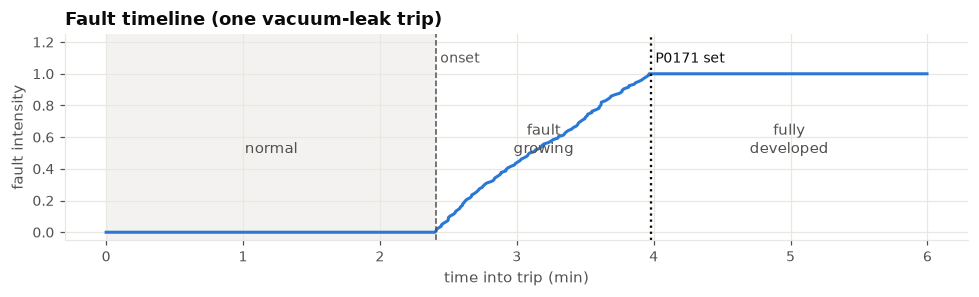

In [4]:
example_label = labels[labels["fault"] == "vacuum_leak"].iloc[0]
trip = logs[(logs["vehicle_id"] == example_label.vehicle_id) & (logs["trip_id"] == example_label.trip_id)]
minutes = trip["time_ms"] / 60_000
onset, dtc = example_label.onset_time_ms / 60_000, example_label.dtc_time_ms / 60_000

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(minutes, trip["fault_intensity"], color=BLUE)
ax.axvline(onset, color=TEXT_2, lw=1, ls="--")
ax.axvline(dtc, color=TEXT, lw=1.5, ls=":")
ax.text(onset, 1.05, " onset", color=TEXT_2, fontsize=9, va="bottom")
ax.text(dtc, 1.05, f" {example_label.dtc_codes} set", color=TEXT, fontsize=9, va="bottom")
ax.axvspan(0, onset, color=GRID, alpha=0.5, lw=0)
ax.text(onset / 2, 0.5, "normal", ha="center", color=TEXT_2)
ax.text((onset + dtc) / 2, 0.5, "fault\ngrowing", ha="center", color=TEXT_2)
ax.text((dtc + minutes.max()) / 2, 0.5, "fully\ndeveloped", ha="center", color=TEXT_2)
ax.set_ylim(-0.05, 1.25); ax.set_ylabel("fault intensity")
ax.set_xlabel("time into trip (min)")
ax.set_title("Fault timeline (one vacuum-leak trip)")
plt.tight_layout()

The gap between onset and DTC is the window in which the signals have already changed but no code exists yet. That is where the anomaly detector can give an **early warning**.

## 3. The six faults, before and after

For one trip per fault: the original signal (grey) and the same signal with the fault injected (blue). The shaded area is where the fault is active, and the dotted line is where its DTC is set.

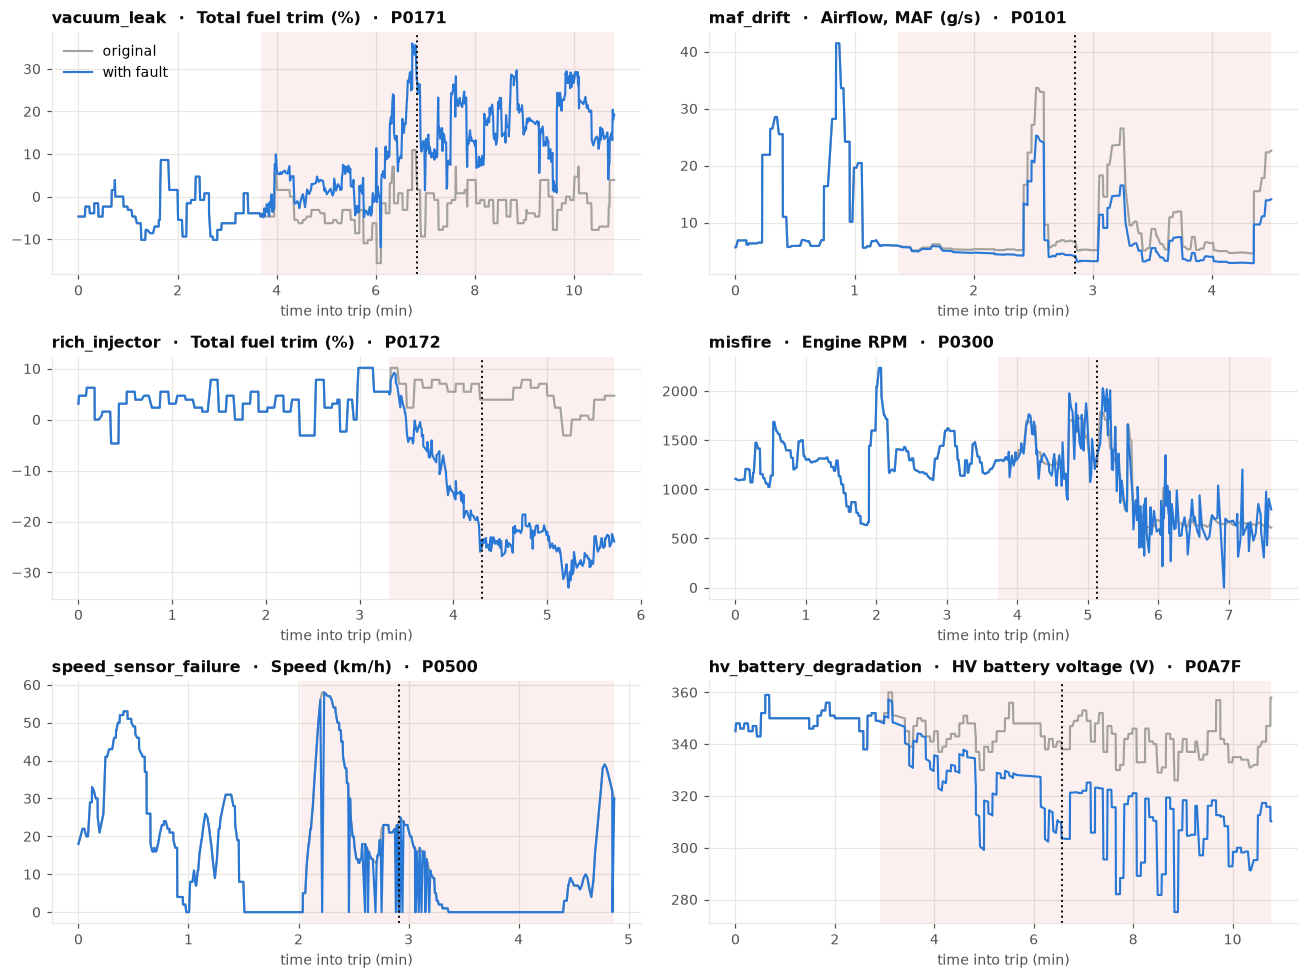

In [5]:
VIEW = {
    "vacuum_leak": ("total_trim", "Total fuel trim (%)"),
    "maf_drift": ("maf_gs", "Airflow, MAF (g/s)"),
    "rich_injector": ("total_trim", "Total fuel trim (%)"),
    "misfire": ("engine_rpm", "Engine RPM"),
    "speed_sensor_failure": ("speed_kmh", "Speed (km/h)"),
    "hv_battery_degradation": ("hv_battery_voltage_v", "HV battery voltage (V)"),
}

def pick_trip(fault):
    # a mid-length trip of this fault, so the example is neither tiny nor huge
    rows = logs[logs["fault"] == fault]
    if fault == "maf_drift":   # prefer a trip with steady airflow (hybrids often read 0 with the engine off)
        steady = rows.groupby(["vehicle_id", "trip_id"])["maf_gs_orig"].median() > 5
        rows = rows.set_index(["vehicle_id", "trip_id"]).loc[steady[steady].index].reset_index()
    sizes = rows.groupby(["vehicle_id", "trip_id"]).size().sort_values()
    key = sizes.index[len(sizes) // 2]
    label = labels.set_index(["vehicle_id", "trip_id"]).loc[key]
    return logs[(logs["vehicle_id"] == key[0]) & (logs["trip_id"] == key[1])], label

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for ax, (fault, (column, title)) in zip(axes.flat, VIEW.items()):
    trip, label = pick_trip(fault)
    t = trip["time_ms"] / 60_000
    ax.axvspan(label.onset_time_ms / 60_000, t.max(), color=FAULT_SHADE, alpha=0.08, lw=0)
    ax.plot(t, trip[f"{column}_orig"], color=MUTED, lw=1.4, label="original")
    ax.plot(t, trip[column], color=BLUE, lw=1.4, label="with fault")
    ax.axvline(label.dtc_time_ms / 60_000, color=TEXT, lw=1.3, ls=":")
    ax.set_title(f"{fault}  ·  {title}  ·  {label.dtc_codes}", fontsize=10.5)
    ax.set_xlabel("time into trip (min)", fontsize=9)
axes[0, 0].legend(loc="upper left", fontsize=9)
plt.tight_layout()

- **Vacuum leak / rich injector:** the ECU corrects the mixture, so the total fuel trim drifts up (lean) or down (rich) from its usual level.
- **MAF drift:** the airflow reading falls below the real value. The fuel trims also rise (not shown), because the ECU injects too little fuel and has to compensate.
- **Misfire:** RPM gets noisier, with sudden dips, while the overall shape of the drive is unchanged.
- **Speed sensor failure:** the speed reading intermittently drops to 0 km/h while the car is clearly moving.
- **Hybrid battery degradation:** voltage sags further below normal, especially under load.

Before the onset the two lines are identical: the injected trips are real driving until the fault starts.

## 4. How strong are the faults compared with normal driving?

A fault that stays inside normal variation would be undetectable, and a real ECU would not store a code for it either. The sizes are therefore set near the levels at which a real ECU stores the DTC (for example about ±25% total fuel trim for P0171 / P0172).

The charts compare the key measure in **normal trips** with the **same trips' fully developed fault periods**.

,measure,normal (median),normal 99th pct,full fault (median)
fault,,,,
vacuum_leak,Total fuel trim (%),0.78,10.94,19.08
rich_injector,Total fuel trim (%),0.78,10.94,-21.66
maf_drift,Airflow vs original reading (%),0.00,NaN,-42.97
misfire,"RPM jumpiness (rpm, |2nd difference|)",15.00,"1,408.00",358.00
speed_sensor_failure,Speed reads 0 while RPM > 1000 (% of readings),1.13,NaN,17.82
hv_battery_degradation,Battery voltage vs original (V),0.00,NaN,-23.99


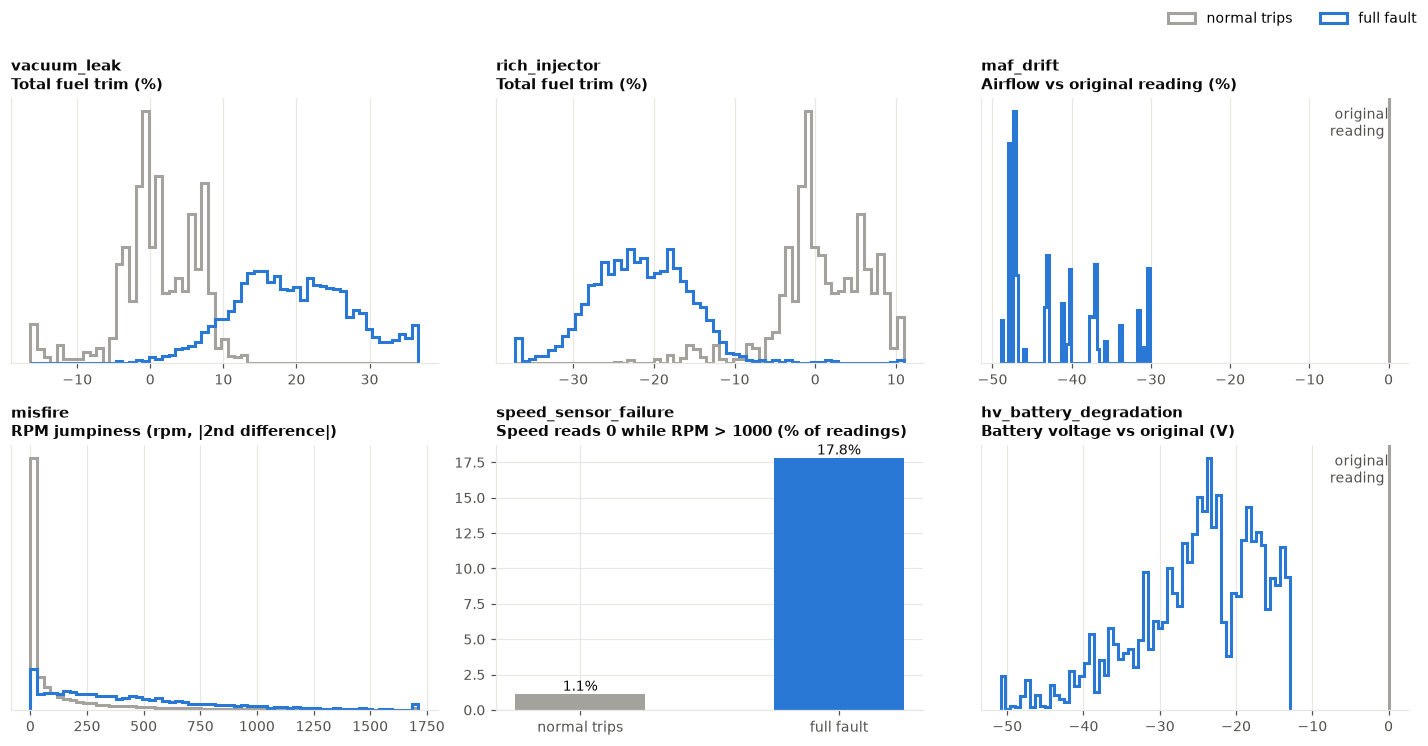

In [6]:
normal = logs[logs["fault"] == NO_FAULT]

def full(fault):
    return logs[(logs["fault"] == fault) & (logs["fault_intensity"] == 1)]

def rpm_jerk(df):
    # absolute second difference of RPM within each trip: how jumpy the engine speed is
    step = df.groupby(["vehicle_id", "trip_id"])["engine_rpm"].diff()
    return step.groupby([df["vehicle_id"], df["trip_id"]]).diff().abs()

def voltage_drop(df):
    return df["hv_battery_voltage_v"] - df["hv_battery_voltage_v_orig"]

MEASURES = [
    ("vacuum_leak", "Total fuel trim (%)", lambda d: d["total_trim"]),
    ("rich_injector", "Total fuel trim (%)", lambda d: d["total_trim"]),
    ("maf_drift", "Airflow vs original reading (%)", lambda d: 100 * (d["maf_gs"] / d["maf_gs_orig"] - 1)),
    ("misfire", "RPM jumpiness (rpm, |2nd difference|)", rpm_jerk),
    ("speed_sensor_failure", "Speed reads 0 while RPM > 1000 (% of readings)", None),
    ("hv_battery_degradation", "Battery voltage vs original (V)", voltage_drop),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6.8))
summary = []
for ax, (fault, title, measure) in zip(axes.flat, MEASURES):
    if measure is None:   # speed dropouts: compare a rate, shown as two bars
        rate = lambda d: 100 * ((d["speed_kmh"] == 0) & (d["engine_rpm"] > 1000)).mean()
        values = {"normal trips": rate(normal), "full fault": rate(full(fault))}
        ax.bar(list(values), list(values.values()), color=[MUTED, BLUE], width=0.5)
        for x, v in enumerate(values.values()):
            ax.text(x, v, f"{v:.1f}%", ha="center", va="bottom", color=TEXT, fontsize=9)
        ax.set_title(f"{fault}\n{title}", fontsize=10)
        summary.append({"fault": fault, "measure": title, "normal (median)": values["normal trips"],
                        "normal 99th pct": np.nan, "full fault (median)": values["full fault"]})
        continue
    base = measure(normal).dropna() if fault not in ("maf_drift", "hv_battery_degradation") else pd.Series([0.0])
    faulty = measure(full(fault)).dropna()
    lo, hi = np.nanpercentile(np.r_[base, faulty], [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    if len(base) > 1:
        ax.hist(base.clip(lo, hi), bins=bins, density=True, histtype="step", color=MUTED, lw=2, label="normal trips")
    else:
        ax.axvline(0, color=MUTED, lw=2)
        ax.text(0, 0.97, "original\nreading ", transform=ax.get_xaxis_transform(), ha="right", va="top",
                color=TEXT_2, fontsize=9)
    ax.hist(faulty.clip(lo, hi), bins=bins, density=True, histtype="step", color=BLUE, lw=2, label="full fault")
    ax.set_title(f"{fault}\n{title}", fontsize=10); ax.set_yticks([])
    summary.append({"fault": fault, "measure": title, "normal (median)": base.median(),
                    "normal 99th pct": base.quantile(0.99) if len(base) > 1 else np.nan,
                    "full fault (median)": faulty.median()})
handles, names = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, names, loc="upper right", ncol=2, fontsize=9)
plt.tight_layout(rect=(0, 0, 1, 0.95))
pd.DataFrame(summary).set_index("fault")

- **Fuel faults** move the total trim well past the normal range: the median full-fault trim lies near or beyond the 99th percentile of normal driving, close to where a real ECU sets P0171 / P0172.
- **MAF drift** cuts the airflow reading by 30–50%, and **battery degradation** pulls voltage down by about 10–50 V. These two are measured against the same trip's original reading (so "normal" is the line at 0); notebook 3 shows how they compare with each vehicle's natural variation.
- **Misfire** is the subtlest: the median RPM jumpiness rises from about 15 to about 360 rpm, but normal driving has a long tail (99th percentile about 1,400 rpm, from gear changes and pulling away). At about 1 reading per second, a misfire looks a lot like ordinary hard driving, which is why it is the hardest fault to catch early.
- **Speed dropouts** are rare in normal trips (mostly brief stops while revving) but frequent once the sensor fails.

> **Calibration lesson.** In the first version, the fuel faults shifted the trim by only about 10% at full intensity, inside normal variation, yet still "set" P0171. The detector could not find them, and no real ECU would have set a code. Sizes were raised to match real DTC thresholds, which is what the table above reflects.

## 5. How much time is there for an early warning?

The time between onset and DTC is the longest possible early warning, if a detector noticed the very first change.

,seconds
min,8.30
25%,52.95
50%,86.85
75%,161.45
max,945.70


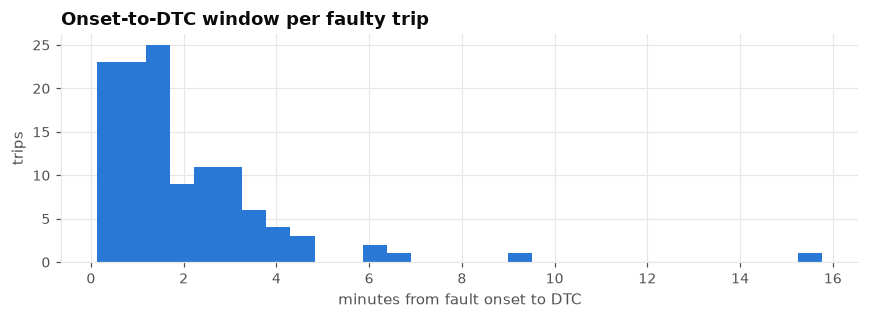

In [7]:
faulty_labels = labels[labels["fault"] != NO_FAULT].copy()
faulty_labels["window_s"] = (faulty_labels["dtc_time_ms"] - faulty_labels["onset_time_ms"]) / 1000

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(faulty_labels["window_s"] / 60, bins=30, color=BLUE)
ax.set_xlabel("minutes from fault onset to DTC"); ax.set_ylabel("trips")
ax.set_title("Onset-to-DTC window per faulty trip")
plt.tight_layout()
faulty_labels["window_s"].describe()[["min", "25%", "50%", "75%", "max"]].to_frame("seconds")

The window is short: a median of about 1.5 minutes, with half of the trips between roughly 50 seconds and 2.7 minutes, because trips are short (median under 7 minutes, notebook 1) and the ramp covers 40% of the remaining trip. Early in the window the fault is still tiny, so a realistic detector can only warn during the later part of the ramp, which is why the measured warnings in notebook 3 are tens of seconds rather than minutes.

## 6. Limitations

- **Simplified physics.** Each fault changes one or two signals with a simple rule. Real faults interact with temperature, load and ECU strategy in more complex ways.
- **One fault per trip, always ending in a DTC.** Real vehicles can have several faults, intermittent faults, or faults that never set a code.
- **Ramp within one trip.** Real parts often degrade over weeks; here everything happens within minutes.
- **Same week for training and injection.** The injected trips are excluded from training, but they come from the same vehicles and week.

The numbers in later notebooks therefore show that the **method** works on realistic signal changes, not how it would perform on real failures.

## 7. Summary

| | |
|---|---|
| Dataset | 240 trips (120 normal, 20 per fault type), 1 week of real VED driving |
| Faults | Vacuum leak, MAF drift, rich injector, misfire, speed sensor failure, hybrid battery degradation |
| Timeline | Onset at 20–60% of the trip, gradual ramp, DTC set when fully developed |
| Fault size | Calibrated near real DTC thresholds; misfire is the hardest to separate from normal driving |
| Labels | Fault type, onset time and DTC time for every trip |

**Next:** `03_anomaly_detection.ipynb`, how the model finds these faults and how early.